# Customer Segmentation Analysis

This notebook prepares customer data, segments customers with K-Means clustering, and compares the resulting groups.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load the Data

In [3]:
data = pd.read_csv(r"D:\ML\internship\majorProject\marketing_campaign.csv", sep='\t')
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

## 2. Clean and Engineer Features

In [4]:
df = data.drop(['ID','Z_Revenue','Response'], axis=1)
df["TotalAcceptedCmp"] = (
    df["AcceptedCmp1"] +
    df["AcceptedCmp2"] +
    df["AcceptedCmp3"] + 
    df["AcceptedCmp4"] +
    df["AcceptedCmp5"]
)

In [5]:
df.drop(['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5'], axis=1, inplace=True)

In [6]:
# df.info()
df

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Z_CostContact,TotalAcceptedCmp
0,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,...,88,88,3,8,10,4,7,0,3,0
1,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,...,1,6,2,1,1,2,5,0,3,0
2,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,...,21,42,1,8,2,10,4,0,3,0
3,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,...,3,5,2,2,0,4,6,0,3,0
4,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,...,27,15,5,5,3,6,5,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,...,118,247,2,9,3,4,5,0,3,0
2236,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,...,0,8,7,8,2,5,7,0,3,1
2237,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,...,12,24,1,2,3,13,6,0,3,1
2238,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,30,...,30,61,2,6,5,10,3,0,3,0


In [7]:
df["Education"].unique()
df.drop_duplicates()
if pd.api.types.is_datetime64_any_dtype(df["Year_Birth"]):
    birth_year = df["Year_Birth"].dt.year
else:
    birth_year = pd.to_numeric(df["Year_Birth"], errors="coerce")
df["Age"] = 2026 - birth_year
df.drop(columns="Year_Birth", inplace=True)
df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Z_CostContact,TotalAcceptedCmp,Age
0,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,...,88,3,8,10,4,7,0,3,0,69
1,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,...,6,2,1,1,2,5,0,3,0,72
2,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,...,42,1,8,2,10,4,0,3,0,61
3,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,...,5,2,2,0,4,6,0,3,0,42
4,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,...,15,5,5,3,6,5,0,3,0,45


In [8]:
spending_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df["TotalSpending"] = df[spending_cols].sum(axis=1)
df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Z_CostContact,TotalAcceptedCmp,Age,TotalSpending
0,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,...,3,8,10,4,7,0,3,0,69,1617
1,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,...,2,1,1,2,5,0,3,0,72,27
2,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,...,1,8,2,10,4,0,3,0,61,776
3,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,...,2,2,0,4,6,0,3,0,42,53
4,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,...,5,5,3,6,5,0,3,0,45,422


In [9]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")

In [10]:
df["customerTenure"] = (
    df["Dt_Customer"].max() - df["Dt_Customer"]
)

df.drop(columns="Dt_Customer",inplace=True)
df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Z_CostContact,TotalAcceptedCmp,Age,TotalSpending,customerTenure
0,Graduation,Single,58138.0,0,0,58,635,88,546,172,...,8,10,4,7,0,3,0,69,1617,663 days
1,Graduation,Single,46344.0,1,1,38,11,1,6,2,...,1,1,2,5,0,3,0,72,27,113 days
2,Graduation,Together,71613.0,0,0,26,426,49,127,111,...,8,2,10,4,0,3,0,61,776,312 days
3,Graduation,Together,26646.0,1,0,26,11,4,20,10,...,2,0,4,6,0,3,0,42,53,139 days
4,PhD,Married,58293.0,1,0,94,173,43,118,46,...,5,3,6,5,0,3,0,45,422,161 days


In [11]:
df.describe()["Age"]

count    2240.000000
mean       57.194196
std        11.984069
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max       133.000000
Name: Age, dtype: float64

In [12]:
categorical_cols = df.select_dtypes(include=["object","string"]).columns
numerical_cols = df.select_dtypes(include="number").columns

In [13]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)
values = encoder.fit_transform(df[categorical_cols])
names = encoder.get_feature_names_out(categorical_cols)

df[names] = values
df.drop(columns=categorical_cols,inplace=True)
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,58138.0,0,0,58,635,88,546,172,88,88,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,71613.0,0,0,26,426,49,127,111,21,42,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,26646.0,1,0,26,11,4,20,10,3,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [14]:
df["Income"] = df.Income.fillna(df["Income"].mean())

## 3. Prepare Data for Clustering

In [15]:
from sklearn.preprocessing import MinMaxScaler

# Exclude timedelta columns because MinMaxScaler only accepts numeric values.
numerical_cols = df.select_dtypes(include="number", exclude="timedelta").columns
scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,0.084832,0.0,0.0,0.585859,0.425318,0.442211,0.316522,0.664093,0.334601,0.243094,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.067095,0.5,0.5,0.383838,0.007368,0.005025,0.003478,0.007722,0.003802,0.016575,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.105097,0.0,0.0,0.262626,0.285332,0.246231,0.073623,0.428571,0.079848,0.116022,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.037471,0.5,0.0,0.262626,0.007368,0.020101,0.011594,0.038610,0.011407,0.013812,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.085065,0.5,0.0,0.949495,0.115874,0.216080,0.068406,0.177606,0.102662,0.041436,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [16]:
x = df[["Income","TotalSpending"]].fillna(df[["Income","TotalSpending"]].mean())

## 4. Build Customer Segments

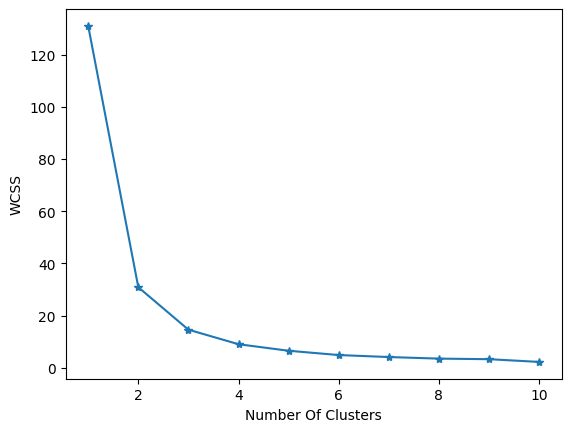

In [17]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss,marker="*")
plt.xlabel("Number Of Clusters")
plt.ylabel("WCSS")
plt.show()

In [18]:
df["Income"] = df["Income"].fillna(df["Income"].mean())

In [42]:
kmeans = KMeans(
    n_clusters=4,
    random_state=1
)
kmeans.fit(x)
df.loc[x.index, "Cluster"] = kmeans.labels_

## 5. Interpret the Customer Segments

In [43]:
df.groupby("Cluster")[["Income","TotalSpending"]].mean()

,Income,TotalSpending
Cluster,,
0.0,69389.395380,1104.832599
1.0,35718.641372,100.072897
2.0,78701.706048,1747.962069
3.0,57485.015277,566.683099


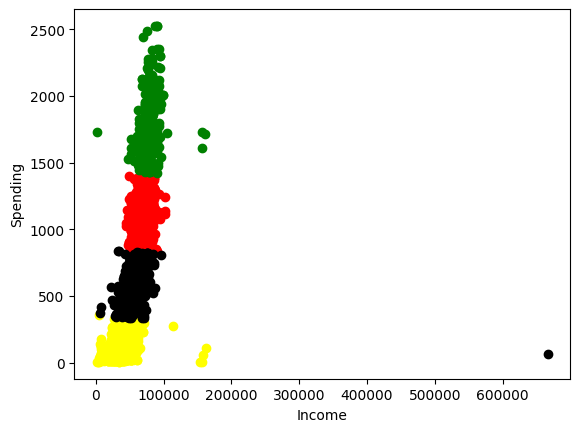

In [44]:
cluster0 = df[df["Cluster"]==0]
cluster1 = df[df["Cluster"]==1]
cluster2 = df[df["Cluster"]==2]
cluster3 = df[df["Cluster"]==3]

plt.scatter(cluster0.Income,cluster0.TotalSpending,color="red")
plt.scatter(cluster1.Income,cluster1.TotalSpending,color="yellow")
plt.scatter(cluster2.Income,cluster2.TotalSpending,color="green")
plt.scatter(cluster3.Income,cluster3.TotalSpending,color="black")
plt.xlabel("Income")
plt.ylabel("Spending")
plt.show()



In [45]:
df.columns

Index(['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Z_CostContact', 'TotalAcceptedCmp', 'Age', 'TotalSpending',
       'customerTenure', 'Education_2n Cycle', 'Education_Basic',
       'Education_Graduation', 'Education_Master', 'Education_PhD',
       'Marital_Status_Absurd', 'Marital_Status_Alone',
       'Marital_Status_Divorced', 'Marital_Status_Married',
       'Marital_Status_Single', 'Marital_Status_Together',
       'Marital_Status_Widow', 'Marital_Status_YOLO', 'Cluster'],
      dtype='str')

In [46]:
cluster0 = cluster0.copy()
cluster1 = cluster1.copy()
cluster2 = cluster2.copy()
cluster3 = cluster3.copy()

cluster0["Children"] = cluster0[["Kidhome", "Teenhome"]].sum(axis=1)
cluster1["Children"] = cluster1[["Kidhome", "Teenhome"]].sum(axis=1)
cluster2["Children"] = cluster2[["Kidhome", "Teenhome"]].sum(axis=1)
cluster3["Children"] = cluster3[["Kidhome", "Teenhome"]].sum(axis=1)

Alone = ["Divorced", "Alone", "Absurd", "Single", "Widow"]
Committed = ["Together", "Married"]

def add_status_group(cluster):
    marital_status = data.loc[cluster.index, "Marital_Status"]
    cluster["StatusGroup"] = np.select(
        [marital_status.isin(Alone), marital_status.isin(Committed)],
        ["Alone", "Committed"],
        default="Other"
    )
    return cluster

cluster0 = add_status_group(cluster0)
cluster1 = add_status_group(cluster1)
cluster2 = add_status_group(cluster2)
cluster3 = add_status_group(cluster3)

In [49]:
df[numerical_cols] = scaler.inverse_transform(df[numerical_cols])

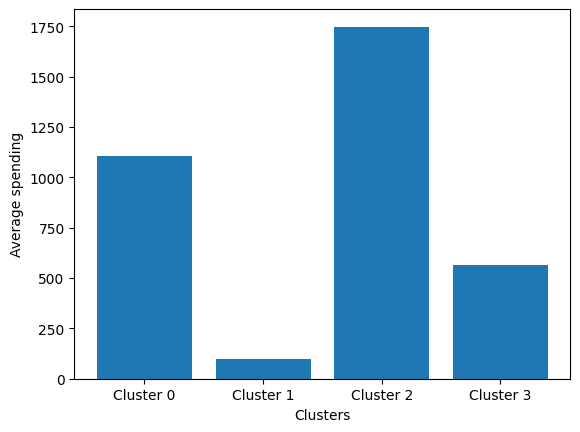

In [47]:
clusters = [cluster0, cluster1, cluster2, cluster3]
cluster_names = ["Cluster 0", "Cluster 1", "Cluster 2", "Cluster 3"]
average_spending = [cluster["TotalSpending"].mean() for cluster in clusters]

plt.bar(cluster_names, average_spending)
plt.xlabel("Clusters")
plt.ylabel("Average spending")
plt.show()

In [ ]:
cluster0["StatusGroup"].value_counts()["Alone"]

def npeople(cluster,column,row):
    return cluster[column].value_counts(row)

npeople(cluster0,"StatusGroup","Alone")
npeople(cluster0,"StatusGroup","Commit") #Alone 0.363436 Children 28 Age 23 69k

npeople(cluster1,"StatusGroup","Alone")
npeople(cluster1,"StatusGroup","Commit") #Alone 0.349533 Children 62 MeanAge 24 Salary 35k

npeople(cluster2,"StatusGroup","Alone")
npeople(cluster2,"StatusGroup","Commit") #Alone 0.372414 Children 12 25.5 Salary 78k

npeople(cluster3,"StatusGroup","Alone")
npeople(cluster3,"StatusGroup","Commit") #Alone 0.345070 Children 52 29 Salary 57k

StatusGroup
Committed    0.650235
Alone        0.345070
Other        0.004695
Name: proportion, dtype: float64

In [70]:
cluster0.Income.mean()

np.float64(69389.39538041317)

In [57]:
pd.DataFrame({
    "cluster1_age": cluster1.Age.describe(),
    "cluster2_age": cluster2.Age.describe()
})

,cluster1_age,cluster2_age
count,1070.000000,290.000000
mean,55.261682,57.313793
std,11.537255,13.444290
min,30.000000,31.000000
25%,47.000000,47.000000
50%,54.000000,56.000000
75%,63.000000,68.000000
max,133.000000,127.000000


In [62]:
cluster1[["Age","Income","TotalSpending"]].corr()

,Age,Income,TotalSpending
Age,1.000000,0.304776,0.167874
Income,0.304776,1.000000,0.384277
TotalSpending,0.167874,0.384277,1.000000


In [61]:
cluster2[["Age","Income","TotalSpending"]].corr()

,Age,Income,TotalSpending
Age,1.000000,-0.026610,-0.012537
Income,-0.026610,1.000000,0.218433
TotalSpending,-0.012537,0.218433,1.000000


## 6. Compare Purchase Channels

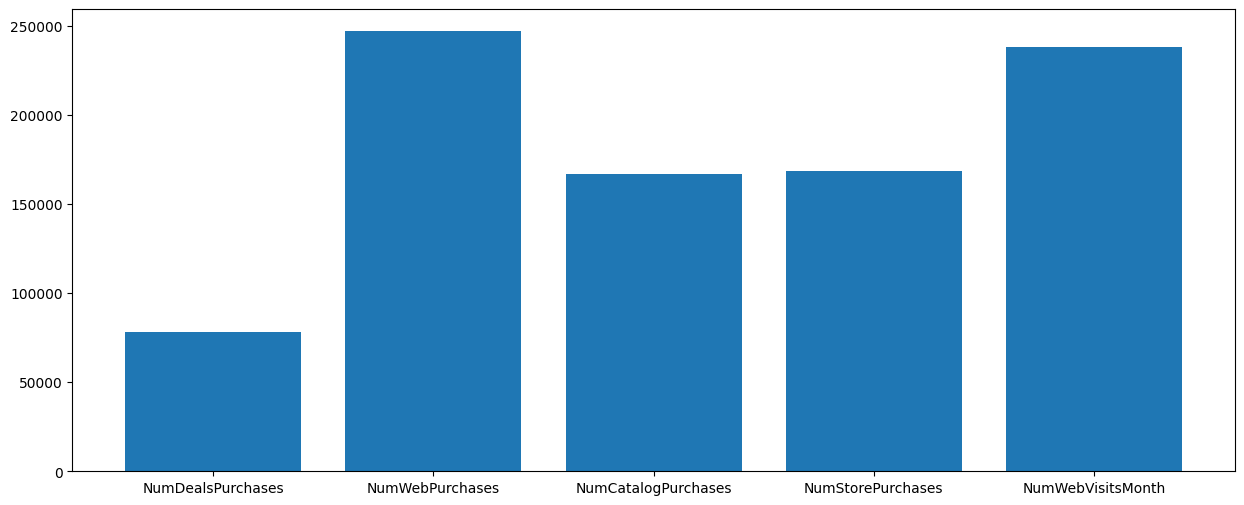

In [85]:
mode_shopping = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']
SUM = df[mode_shopping].sum()
plt.figure(figsize=(15,6))
plt.bar(SUM.index,SUM)
plt.show()

In [150]:
cluster1[mode_shopping].sum()

NumDealsPurchases      2253.0
NumWebPurchases        2344.0
NumCatalogPurchases     597.0
NumStorePurchases      3494.0
NumWebVisitsMonth      6846.0
dtype: float64

In [149]:
cluster2[mode_shopping].sum()

NumDealsPurchases       442.0
NumWebPurchases        1570.0
NumCatalogPurchases    1869.0
NumStorePurchases      2357.0
NumWebVisitsMonth       960.0
dtype: float64

## Conclusion

K-Means clustering separates customers using income and total spending. The cluster summaries show that customer groups differ in purchasing behavior, household profile, and preferred shopping channels. These segments can guide targeted campaigns, such as premium offers for high-value customers and tailored promotions for more price-sensitive groups. The results should be reviewed with the business team before using them for campaign decisions.